# **1. Perkenalan Dataset**


1.  Sumber Dataset
Dataset yang digunakan pada proyek ini adalah Stroke Prediction Dataset yang diperoleh dari Kaggle.

Link Dataset:
https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset

Deskripsi Dataset

Dataset ini digunakan untuk memprediksi kemungkinan seseorang mengalami stroke berdasarkan berbagai faktor kesehatan dan demografi.
Dataset terdiri dari beberapa fitur seperti:

- gender
- age
- hypertension
- heart_disease
- ever_married
- work_type
- Residence_type
- avg_glucose_level
- bmi
- smoking_status

Target pada dataset ini adalah:
- stroke (0 = tidak mengalami stroke, 1 = mengalami stroke)

Dataset ini cocok digunakan untuk permasalahan klasifikasi biner.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [5]:
# Memuat Dataset
df = pd.read_csv("D:\\001-msml\Zaky-MLops\Eksperimen_SML_zaky-main\healthcare-dataset-stroke-data.csv")
df.head()

print("Shape Dataset:")
print(df.shape)

print("\nInformasi Dataset:")
df.info()

df.describe()

Shape Dataset:
(5110, 12)

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Missing Value
Jumlah Duplikat
stroke
0    4861
1     249
Name: count, dtype: int64
stroke
0    95.13
1     4.87
Name: count, dtype: float64


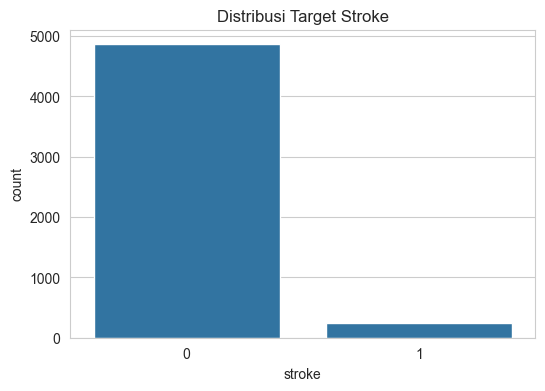

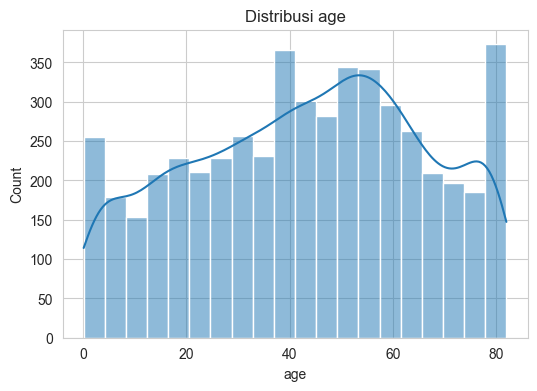

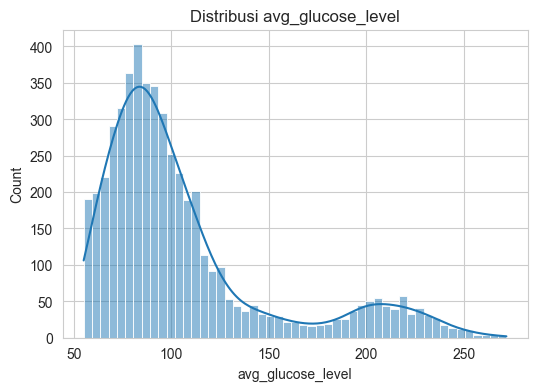

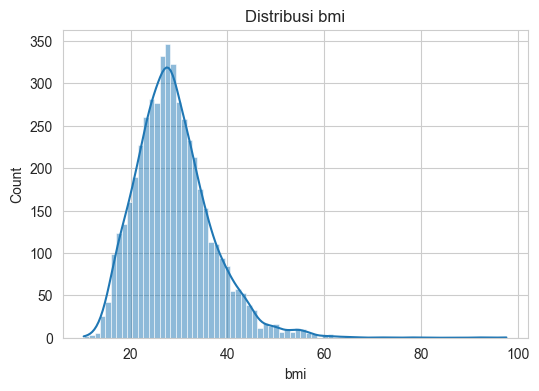

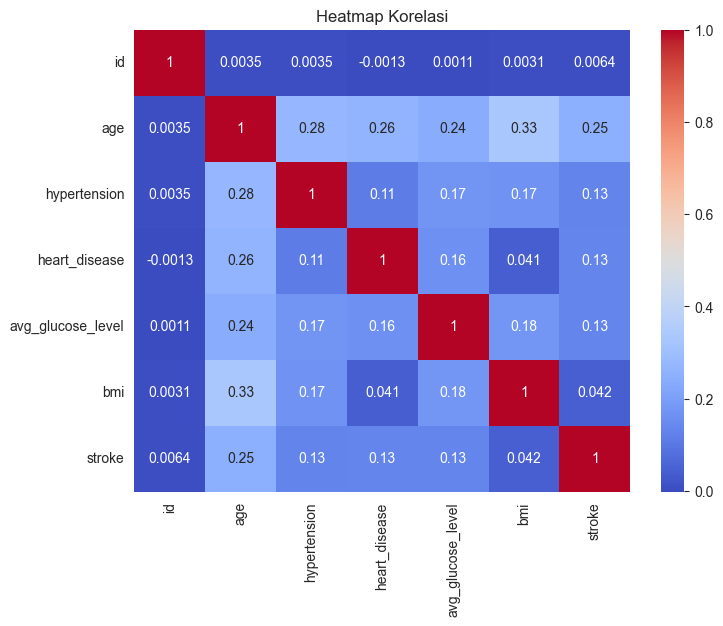

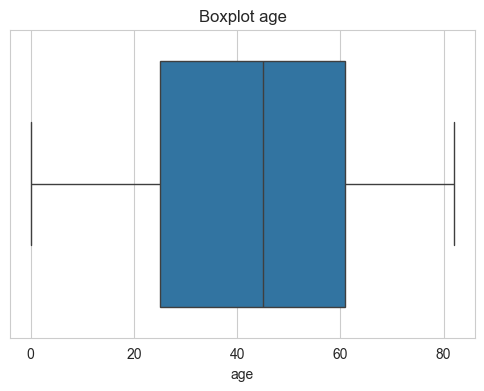

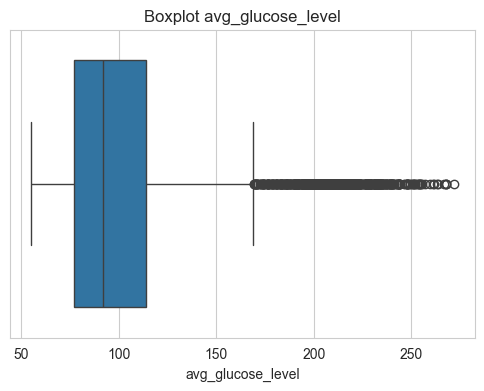

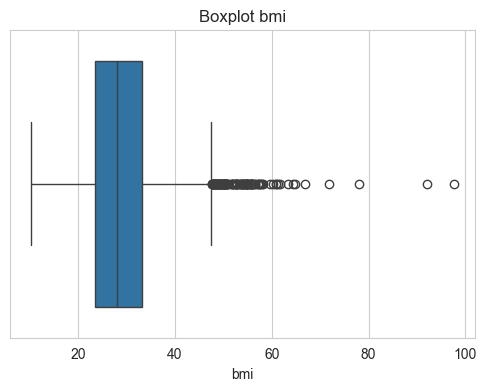

In [6]:
# Missing Value
print("Missing Value")
df.isnull().sum()

# Duplikasi
print("Jumlah Duplikat")
df.duplicated().sum()

# Distribusi target
print(df['stroke'].value_counts())
print((df['stroke'].value_counts()/len(df)*100).round(2))

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='stroke')

plt.title("Distribusi Target Stroke")
plt.show()

# Distribusi numerik
numerical_cols = ['age','avg_glucose_level','bmi']

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)

    plt.title(f'Distribusi {col}')
    plt.show()

# Korelasi
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title('Heatmap Korelasi')
plt.show()

# Detek outlier
for col in ['age','avg_glucose_level','bmi']:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

    plt.title(f'Boxplot {col}')
    plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [12]:
# Missing value pada BMI
df['bmi'].fillna(df['bmi'].median(),inplace=True)

# Hapus duplikat
df = df.drop_duplicates()
print(df.shape)

# Encoding
categorical_cols = ['gender','ever_married','work_type','Residence_type','smoking_status']

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Outler handling (IQR)
for col in ['age','avg_glucose_level','bmi']:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    df[col] = np.where(
        df[col] < lower,
        lower,
        np.where(
            df[col] > upper,
            upper,
            df[col]
        )
    )

# Scaling
X_cols = df.drop('stroke',axis=1).columns
scaler = StandardScaler()

df[X_cols] = scaler.fit_transform(
    df[X_cols]
)

# tampil 5 data awal setelah preprocessing
df.head()

(5110, 11)


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1.188073,1.051434,-0.328602,4.185032,0.723884,-0.153836,0.984080,2.058363,1.110872,-0.351781,1
1,-0.840344,0.786070,-0.328602,-0.238947,0.723884,0.763438,-1.016178,2.058363,-0.082921,0.581552,1
2,1.188073,1.626390,-0.328602,4.185032,0.723884,-0.153836,-1.016178,0.148256,0.535043,0.581552,1
3,-0.840344,0.255342,-0.328602,-0.238947,0.723884,-0.153836,0.984080,2.058363,0.801890,1.514885,1
4,-0.840344,1.582163,3.043196,-0.238947,0.723884,0.763438,-1.016178,2.058363,-0.658751,0.581552,1


In [13]:
df.to_csv(
    'stroke_preprocessing.csv',
    index=False
)

print("Dataset preprocessing berhasil disimpan")

Dataset preprocessing berhasil disimpan
